In this notebook, we applied manual search to find an optimal parameters for Ensemble Kalman Filter.

The parameter to be tuned for Ensemble Kalman Filter is:
- Ensemble (number of samples): from 32 to 4096 samples.

This parameter is chosen based on a balance between processing time and estimation error.

In [1]:
import os
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
from configs import SetupEnum, MeasurementDataEnum, ErrorEnum
from parameter_tuners.ensemble_kalman_filter_parameter_tuner import EnsembleKalmanFilterParameterTuner

%matplotlib inline
np.random.seed(777)

In [2]:
n_samples = [int(n) for n in np.logspace(5, 12, base=2, num=8).tolist()]
n_samples

[32, 64, 128, 256, 512, 1024, 2048, 4096]

In [7]:
root_path = "../../../../"

kitti_root_dir = os.path.join(root_path, "data")
file_export_path = os.path.join(root_path, "exports/ensemble_kalman_filter")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")

kitti_date = '2011_09_30'
kitti_drive = '0033'

error_type = ErrorEnum.MAE

run_filter = False
error_weight = 0.9

# Setup1 (IMU, VO)

In [8]:
tuner_setup1 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_1,
    kitti_drive=kitti_drive,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    noise_vector_dir=noise_vector_dir,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [9]:
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

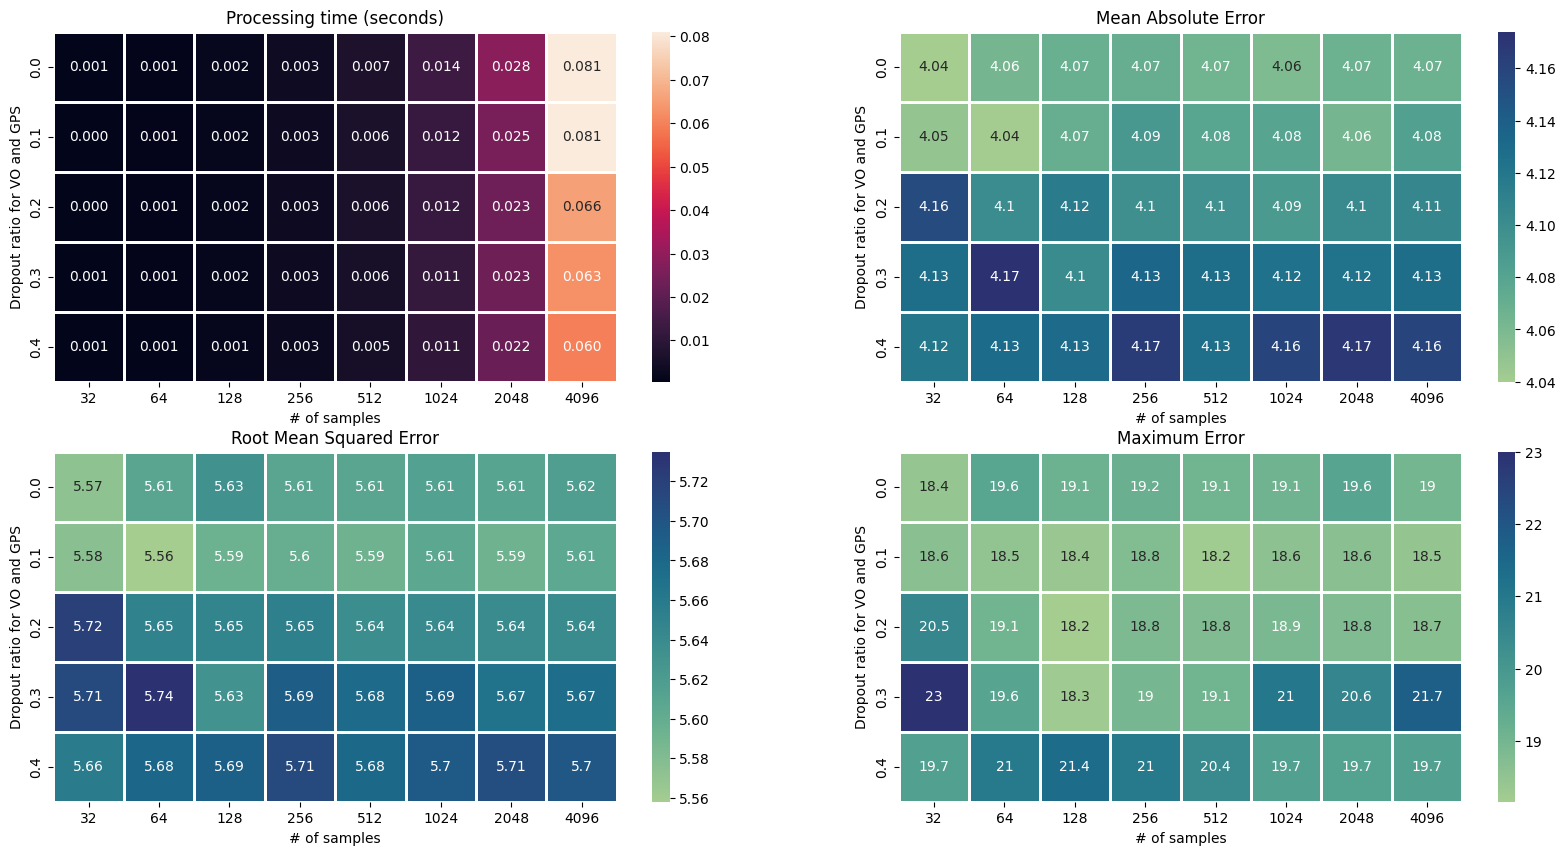

In [10]:
tuner_setup1.plot_results()

In [11]:
params_setup1, df1 = tuner_setup1.find_best_combination(error_weight=error_weight)
print("# of samples")
df1

# of samples


Error types,MAE,RMSE,MAX
No dropout,32,32,32
10% drop,64,64,128
20% drop,64,64,128
30% drop,128,128,128
40% drop,32,32,32


In [12]:
params_setup1

{1: [32, 64, 64, 128, 32],
 2: [32, 64, 64, 128, 32],
 3: [32, 128, 128, 128, 32]}

# Setup2 (IMU, VO+GPS)

In [13]:
tuner_setup2 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_2,
    kitti_drive=kitti_drive,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    noise_vector_dir=noise_vector_dir,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [14]:
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

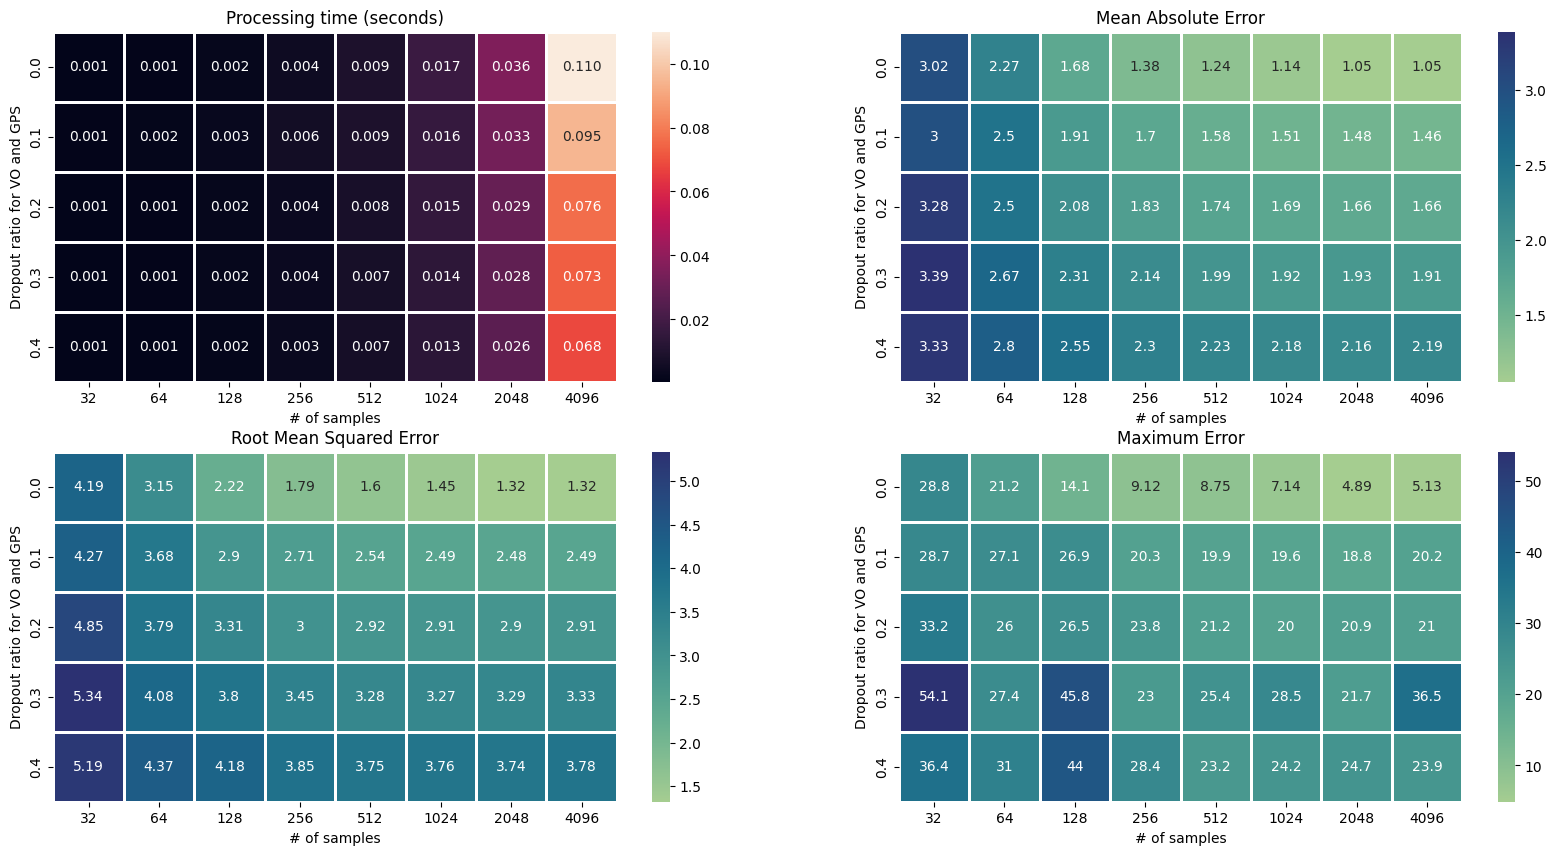

In [15]:
tuner_setup2.plot_results()

In [16]:
params_setup2, df2 = tuner_setup2.find_best_combination(error_weight=error_weight)
print("# of samples")
df2

# of samples


Error types,MAE,RMSE,MAX
No dropout,2048,2048,2048
10% drop,1024,1024,2048
20% drop,1024,512,1024
30% drop,1024,512,256
40% drop,1024,512,512


In [17]:
params_setup2

{1: [2048, 1024, 1024, 1024, 1024],
 2: [2048, 1024, 512, 512, 512],
 3: [2048, 2048, 1024, 256, 512]}

# Setup3 (INS)

In [18]:
tuner_setup3 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_3,
    kitti_drive=kitti_drive,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    noise_vector_dir=noise_vector_dir,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [19]:
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

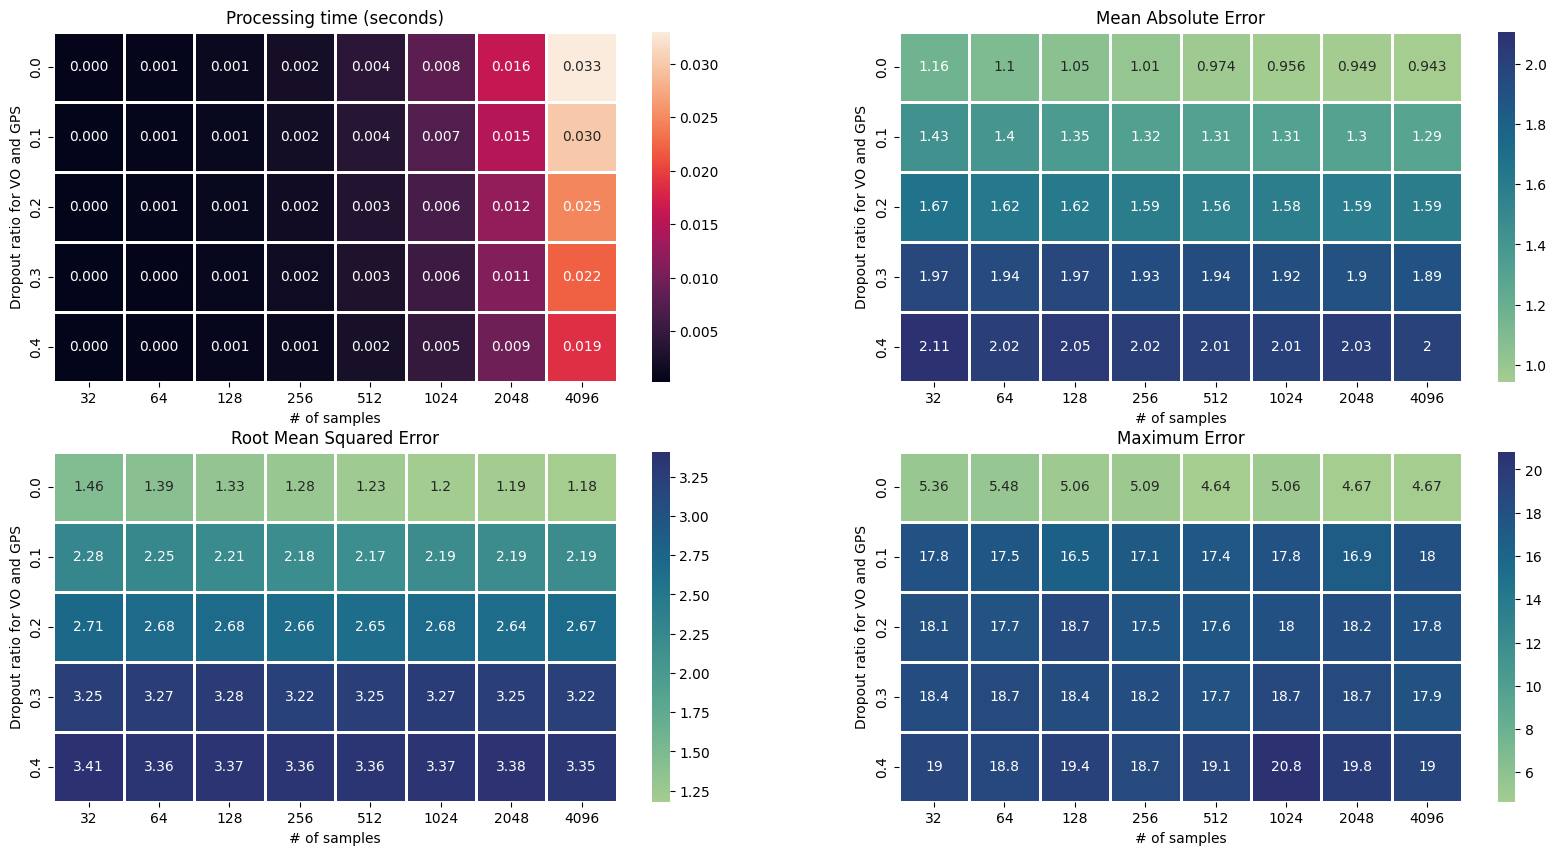

In [20]:
tuner_setup3.plot_results()

In [21]:
params_setup3, df3 = tuner_setup3.find_best_combination(error_weight=error_weight)
print("# of samples")
df3

# of samples


Error types,MAE,RMSE,MAX
No dropout,1024,1024,512
10% drop,256,256,128
20% drop,512,256,256
30% drop,64,256,512
40% drop,64,64,64


In [22]:
params_setup3

{1: [1024, 256, 512, 64, 64],
 2: [1024, 256, 256, 256, 64],
 3: [512, 128, 256, 512, 64]}

# Results

In [23]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)']],
                                            names=['# of ensemble'])

In [24]:
params_setup1_mae = np.array(params_setup1[ErrorEnum.MAE.value]).reshape(-1, 1)
params_setup2_mae = np.array(params_setup2[ErrorEnum.MAE.value]).reshape(-1, 1)
params_setup3_mae = np.array(params_setup3[ErrorEnum.MAE.value]).reshape(-1, 1)
best_params_mae = np.concatenate([params_setup1_mae, params_setup2_mae, params_setup3_mae], axis=1)
results_df_mae = pd.DataFrame(best_params_mae, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### MAE: optimal number of samples

In [25]:
results_df_mae

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,32,2048,1024
10% drop,64,1024,256
20% drop,64,1024,512
30% drop,128,1024,64
40% drop,32,1024,64


In [26]:
params_setup1_rmse = np.array(params_setup1[ErrorEnum.RMSE.value]).reshape(-1, 1)
params_setup2_rmse = np.array(params_setup2[ErrorEnum.RMSE.value]).reshape(-1, 1)
params_setup3_rmse = np.array(params_setup3[ErrorEnum.RMSE.value]).reshape(-1, 1)
best_params_rmse = np.concatenate([params_setup1_rmse, params_setup2_rmse, params_setup3_rmse], axis=1)
results_df_rmse = pd.DataFrame(best_params_rmse, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### RMSE: optimal number of samples

In [27]:
results_df_rmse

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,32,2048,1024
10% drop,64,1024,256
20% drop,64,512,256
30% drop,128,512,256
40% drop,32,512,64


In [28]:
params_setup1_max = np.array(params_setup1[ErrorEnum.MAX.value]).reshape(-1, 1)
params_setup2_max = np.array(params_setup2[ErrorEnum.MAX.value]).reshape(-1, 1)
params_setup3_max = np.array(params_setup3[ErrorEnum.MAX.value]).reshape(-1, 1)
best_params_max = np.concatenate([params_setup1_max, params_setup2_max, params_setup3_max], axis=1)
results_df_max = pd.DataFrame(best_params_max, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### Maximum Errror: optimal number of samples

In [29]:
results_df_max

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,32,2048,512
10% drop,128,2048,128
20% drop,128,1024,256
30% drop,128,256,512
40% drop,32,512,64


In [41]:
results_df_mae.to_json(os.path.join(file_export_path, "0033_best_params.json"))

# Conclusion

In this notebook, we conducted an experiment that applies manual search to find an optimal parameter, specifically ensemble size, for Ensemble Kalman Filter. 

According to the experiment, in Setup2 and Setup3 Ensemble Kalman Filter is susceptible to data drop in terms of MAX error, where even 10% of data drop increases the MAX error significantly.

Considering MAE, we found that the optimal ensemble size for each setup when no data drop is:
- Setup1 (IMU, VO): 64
- Setup2 (IMU, VO+GPS): 2048
- Setup3 (INS, VO+GPS): 1024.